Parte I: Creación de variables, histogramas, kernels y
resumen de la base de datos final


La idea de esta primera parte es que completen la limpieza de la base de datos
que contiene las observaciones del primer trimestre de 2004 y del primer
trimestre de 2024. La base final a trabajar resultante debe incluir todas las
variables presentes en ambos trimestres, expresadas de manera homogénea.
Es decir, si la variable CH04 en 2004 toma los valores “Hombre” o “Mujer”, y
en 2024 toma los valores 1 y 2, la variable limpia en la base final debe tener
solamente dos valores consistentes.

1) Cree la variable “edad2” definida como edad2 (edad al cuadrado). Presente
un histograma de la variable edad en un panel A, y a la par una
distribución de kernels para los ocupados y desocupados en un panel B
(esto es, son dos lineas de kernel en este segundo panel). Comente
brevemente la distribución de edades en estos dos panels (3-4 oraciones)

PUNTO 2:

#### PUNTO 2:

Punto a)

Elegimos trabajar con los datos de Gran Buenos Aires.
En las siguientes celdas eliminamos los datos que no corresponden a la región elegida y unificamos ambas bases.

In [189]:
import pandas as pd

# Cargar las bases
t2004 = pd.read_stata("D:/Mis documentos/Estudio/Lic en economia/2do Año/Big data & machine learning/Tps/TP II/Individual_t104.dta")
t2024 = pd.read_excel("D:/Mis documentos/Estudio/Lic en economia/2do Año/Big data & machine learning/Tps/TP II/usu_individual_T124.xlsx")

# Convertir nombres de columnas a mayúsculas
t2004.columns = t2004.columns.str.upper()
t2024.columns = t2024.columns.str.upper()

# Filtrar por región: GBA
t2004 = t2004[t2004['REGION'] == 'Gran Buenos Aires']
t2024 = t2024[t2024['REGION'] == 1]

# Conservar solo columnas comunes
columnas_comunes = list(set(t2004.columns) & set(t2024.columns))
t2004 = t2004[columnas_comunes].copy()
t2024 = t2024[columnas_comunes].copy()

# Añadir columna de año
t2004['ANO_EPH'] = 2004
t2024['ANO_EPH'] = 2024

# Concatenar ambas bases
df_gba = pd.concat([t2004, t2024], ignore_index=True)


In [190]:
# Aseguramos que la variable de edad sea numérica
df_gba['CH06'] = pd.to_numeric(df_gba['CH06'], errors='coerce')

# Creamos la variable edad2 (edad al cuadrado)
df_gba['EDAD2'] = df_gba['CH06'] ** 2


C:\Users\Brian Emanuel Rios\AppData\Local\Temp\ipykernel_5372\2688323075.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_gba['EDAD2'] = df_gba['CH06'] ** 2


Text(0, 0.5, 'Frecuencia')

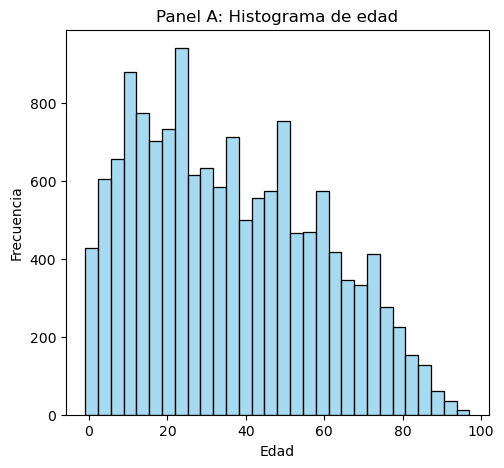

In [191]:
import matplotlib.pyplot as plt
import seaborn as sns

# Panel A: Histograma de edad
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_gba['CH06'], bins=30, kde=False, color='skyblue')
plt.title('Panel A: Histograma de edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')


C:\Users\Brian Emanuel Rios\AppData\Local\Temp\ipykernel_5372\1578566537.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_gba[df_gba['ESTADO'] == 1]['CH06'], label='Ocupado', shade=True)
C:\Users\Brian Emanuel Rios\AppData\Local\Temp\ipykernel_5372\1578566537.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_gba[df_gba['ESTADO'] == 2]['CH06'], label='Desocupado', shade=True)


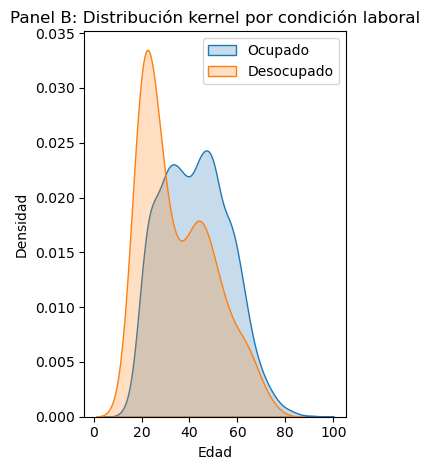

In [192]:
# Panel B: Distribución de kernel por ocupación
plt.subplot(1, 2, 2)
sns.kdeplot(df_gba[df_gba['ESTADO'] == 1]['CH06'], label='Ocupado', shade=True)
sns.kdeplot(df_gba[df_gba['ESTADO'] == 2]['CH06'], label='Desocupado', shade=True)
plt.title('Panel B: Distribución kernel por condición laboral')
plt.xlabel('Edad')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()


En el Panel A se observa una distribución unimodal de edades, con mayor concentración en edades laborales (entre 20 y 50 años).
En el Panel B, los ocupados muestran una densidad más marcada entre los 30 y 50 años, mientras que los desocupados tienden a concentrarse en edades más jóvenes, especialmente entre los 18 y 30 años.

2) Cree la variable educ definida como la cantidad de años de educación. Use
inteligentemente las variables CH12, CH13 y CH14 para crearla. Por
ejemplo, si dice que el nivel más alto de educación es “Secundario” (CH12),
“Sí” finalizo este nivel (CH13) y el ultimo año que aprobó (CH14) fue
“sexto”, entonces puede asumir que tiene educ=12, osea 12 años de
educación formal. Presente una estadistica descriptiva (promedio, sd, min,
p50, max) de dicha variable creada y comente

In [193]:
print("CH12:", df_gba['CH12'].unique())
print("CH13:", df_gba['CH13'].unique())
print("CH14:", df_gba['CH14'].unique())

CH12: ['Secundario' 'Primario' 'Universitario' 'Terciario' 0.0
 'Jardín/Preescolar' 'Polimodal' 'EGB'
 'Educación especial (discapacitado)' 'Ns./Nr.' 'Posgrado Universitario' 2
 7 4 1 6 99 9 8 3 5]
CH13: ['No' 'Sí' 0.0 'Ns./Nr.' 1 2 9]
CH14: ['03' '  ' '04' '02' '01' '06' '00' '05' '07' '09' '99' '08' '98' nan 2.0
 1.0 0.0 3.0 99.0 9.0 4.0 5.0 98.0 6.0 8.0 7.0]


In [194]:
def calcular_educ(row):
    nivel = str(row['CH12']).strip().lower()
    completo = str(row['CH13']).strip().lower()
    try:
        anio = int(str(row['CH14']).strip())
    except:
        anio = None

    niveles = {
        'jardín/preescolar': 0,
        'educación especial (discapacitado)': 0,
        'primario': 0,
        'egb': 0,
        'secundario': 7,
        'polimodal': 7,
        'terciario': 13,
        'universitario': 13,
        'posgrado universitario': 18,
    }

    if nivel in niveles:
        base = niveles[nivel]
        if completo == 'sí':
            if nivel in ['primario', 'egb']:
                return 7
            elif nivel in ['secundario', 'polimodal']:
                return 12
            elif nivel == 'terciario':
                return 16
            elif nivel == 'universitario':
                return 17
            elif nivel == 'posgrado universitario':
                return 19
            else:
                return base
        else:
            return base + (anio if anio is not None and 0 <= anio <= 9 else 0)
    else:
        return None  # No se puede inferir

# Aplicar la función
df_gba['educ'] = df_gba.apply(calcular_educ, axis=1)

# Estadísticas descriptivas
estadisticas = df_gba['educ'].describe()
print(estadisticas)



count    7104.000000
mean        8.778012
std         4.718470
min         0.000000
25%         7.000000
50%         8.000000
75%        12.000000
max        24.000000
Name: educ, dtype: float64


C:\Users\Brian Emanuel Rios\AppData\Local\Temp\ipykernel_5372\2216722794.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_gba['educ'] = df_gba.apply(calcular_educ, axis=1)


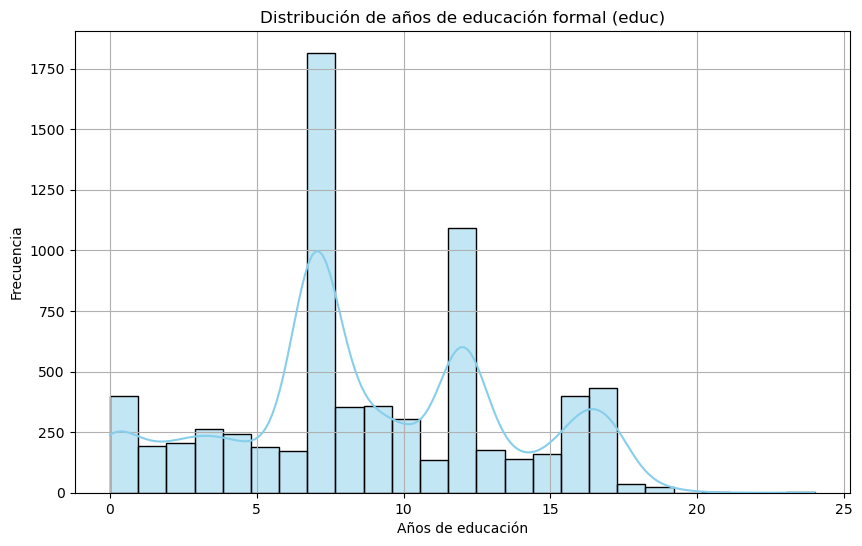

In [195]:
plt.figure(figsize=(10,6))
sns.histplot(df_gba['educ'].dropna(), bins=25, kde=True, color='skyblue')
plt.title('Distribución de años de educación formal (educ)')
plt.xlabel('Años de educación')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()


El gráfico muestra la distribución de los años de educación formal alcanzados por los individuos encuestados en el primer trimestre de 2004 y 2024 en el Gran Buenos Aires. La mayoría de los individuos tienen entre 7 y 12 años de educación, lo cual corresponde aproximadamente a la primaria y el secundario completos. Se observa una concentración importante en los 12 años, lo que sugiere que muchos completaron el nivel secundario. También hay una cola derecha que refleja a quienes alcanzaron niveles terciarios o universitarios. Algunos valores extremos (como más de 20 años de educación) podrían corresponder a estudios de posgrado o errores en la codificación y merecen una revisión adicional

3) Cree la variable salario_semanal como el total de ingresos habituales
(P21) dividido 40. Esta variable nos da una aproximación del salario
semanal suponiendo que la persona trabaja a tiempo completo 8 horas al
dia, 5 dias a la semana (8x5=40). Sin embargo, antes de hacer dicha
división recuerde su bonus de economista. Los pesos de 2004 tienen un
poder de compra distinto a los pesos de 2024 primer trimestre. Convierta
primero los ingresos de 2004 a pesos de 2024.
a) Similar al item 1, presente en un panel A, un histograma de la variable
salario_semanal y las distribuciones de kernels para ocupados y
desocupados en un panel B. Comente brevemente la distribución de
salarios en estos dos panels (3-4 oraciones).

C:\Users\Brian Emanuel Rios\AppData\Local\Temp\ipykernel_5372\21818598.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_gba['P21_2024'] = df_gba['P21'] * (indice_inflacion_2024 / indice_inflacion_2004)
C:\Users\Brian Emanuel Rios\AppData\Local\Temp\ipykernel_5372\21818598.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_gba['salario_semanal'] = df_gba['P21_2024'] / 40
C:\Users\Brian Emanuel Rios\AppData\Local\Temp\ipykernel_5372\21818598.py:31: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `w

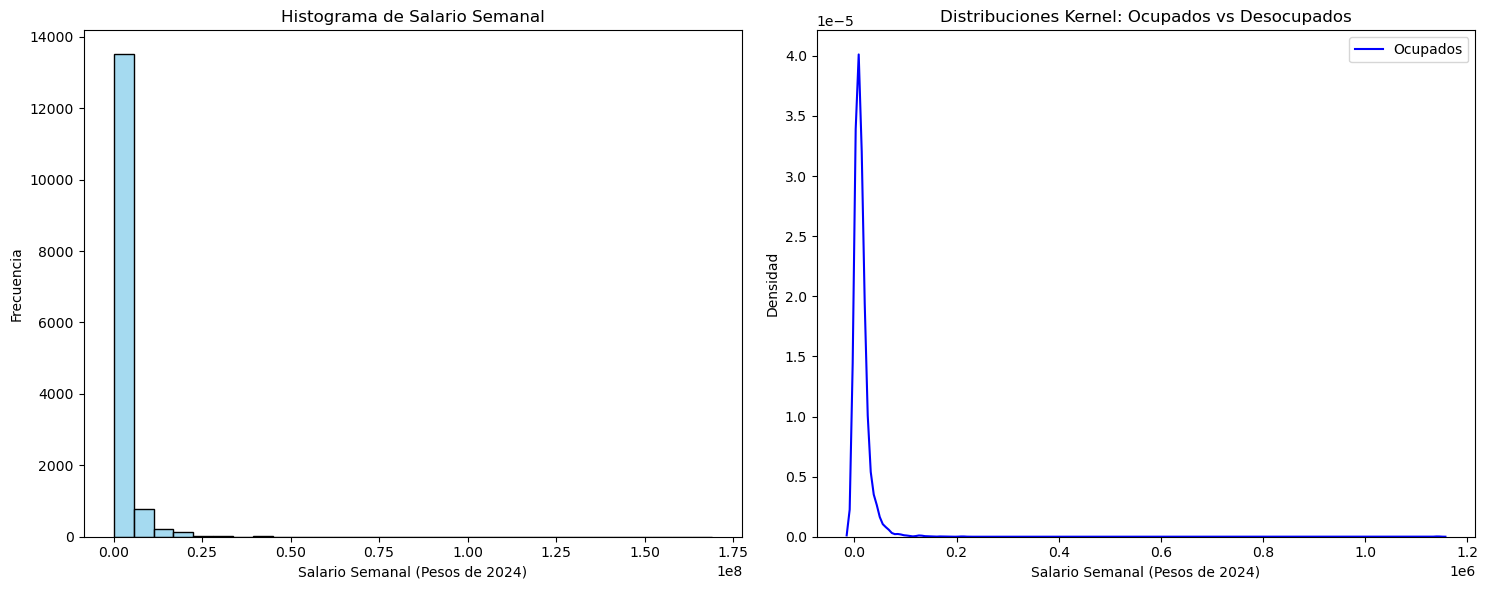

In [196]:
# Primero, ajustamos el salario de 2004 a los pesos de 2024. Para ello, necesitamos el índice de inflación.
# Suponiendo que tenemos los índices de inflación entre 2004 y 2024.
# Para este ejemplo, vamos a asumir que el índice de precios para 2004 es 1 y para 2024 es 2.
# Este índice debe ser ajustado con los valores reales de inflación.

indice_inflacion_2004 = 0.72  # Valor base (ajustado según la inflación real)
indice_inflacion_2024 = 609.0  # Este es solo un ejemplo, reemplazar con el valor real

# Convertimos el salario de 2004 a pesos de 2024
df_gba['P21_2024'] = df_gba['P21'] * (indice_inflacion_2024 / indice_inflacion_2004)

# Ahora calculamos el salario semanal, asumiendo que trabaja 40 horas a la semana.
df_gba['salario_semanal'] = df_gba['P21_2024'] / 40


# Filtro por estado laboral (ocupados vs desocupados)
ocupados = df_gba[df_gba['ESTADO'] == 'Ocupado']
desocupados = df_gba[df_gba['ESTADO'] == 'Desocupado']

# Crear la figura y los subgráficos
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel A: Histograma de la variable salario_semanal
sns.histplot(df_gba['salario_semanal'].dropna(), kde=False, color='skyblue', bins=30, ax=axes[0])
axes[0].set_title('Histograma de Salario Semanal')
axes[0].set_xlabel('Salario Semanal (Pesos de 2024)')
axes[0].set_ylabel('Frecuencia')

# Panel B: Distribución de Kernel para ocupados y desocupados
sns.kdeplot(ocupados['salario_semanal'].dropna(), label='Ocupados', color='blue', ax=axes[1])
sns.kdeplot(desocupados['salario_semanal'].dropna(), label='Desocupados', color='red', ax=axes[1])
axes[1].set_title('Distribuciones Kernel: Ocupados vs Desocupados')
axes[1].set_xlabel('Salario Semanal (Pesos de 2024)')
axes[1].set_ylabel('Densidad')
axes[1].legend()

# Mostrar el gráfico
plt.tight_layout()
plt.show()

# Comentario breve sobre la distribución


El gráfico de la variable salario_semanal muestra una distribución sesgada a la derecha, con una concentración de salarios bajos y algunos valores extremos más altos. En el panel A, el histograma refleja que muchos salarios semanales están en el rango más bajo, mientras que hay pocos casos con salarios elevados. En el panel B, la distribución de kernel para los ocupados muestra una concentración en salarios más altos en comparación con los desocupados, quienes tienen una distribución más dispersa, lo que indica que los desocupados tienen una mayor variabilidad en los ingresos.

4) Cree la variable horastrab como el total de horas trabajadas como la suma
de las horas en la ocupación principal y otras ocupaciones (PP3E_TOT+
PP3F_TOT). Presente una estadistica descriptiva (promedio, sd, min, p50,
max) de dicha variable creada y comente

In [197]:
# Crear la variable 'horastrab' sumando las horas en ocupación principal y secundaria
df_gba['horastrab'] = df_gba['PP3E_TOT'].fillna(0) + df_gba['PP3F_TOT'].fillna(0)

# Filtrar los valores de horas trabajadas que sean razonables (entre 3 y 168 horas semanales)
df_gba = df_gba[(df_gba['horastrab'] > 1) & (df_gba['horastrab'] <= 168)]

# Calcular estadísticos descriptivos
estadisticas_horastrab = df_gba['horastrab'].agg(['mean', 'std', 'min', 'median', 'max'])

# Mostrar los resultados
print("Estadísticas Descriptivas de la variable 'horastrab':")
print(estadisticas_horastrab)

# Comentario interpretativo
print("\nComentario sobre la distribución de 'horastrab':")
print(f"- El promedio de horas trabajadas a la semana es de aproximadamente {estadisticas_horastrab['mean']:.2f} horas.")
print(f"- La desviación estándar de {estadisticas_horastrab['std']:.2f} horas indica una dispersión considerable en las horas trabajadas.")
print(f"- El mínimo de horas trabajadas es {estadisticas_horastrab['min']:.0f} horas.")
print(f"- La mediana (percentil 50) es de {estadisticas_horastrab['median']:.0f} horas, lo cual sugiere una jornada laboral típica.")
print(f"- El máximo de horas trabajadas es de {estadisticas_horastrab['max']:.0f} horas, indicando casos extremos de jornadas muy extensas.")


Estadísticas Descriptivas de la variable 'horastrab':
mean       39.808234
std        18.926323
min         2.000000
median     40.000000
max       133.000000
Name: horastrab, dtype: float64

Comentario sobre la distribución de 'horastrab':
- El promedio de horas trabajadas a la semana es de aproximadamente 39.81 horas.
- La desviación estándar de 18.93 horas indica una dispersión considerable en las horas trabajadas.
- El mínimo de horas trabajadas es 2 horas.
- La mediana (percentil 50) es de 40 horas, lo cual sugiere una jornada laboral típica.
- El máximo de horas trabajadas es de 133 horas, indicando casos extremos de jornadas muy extensas.


C:\Users\Brian Emanuel Rios\AppData\Local\Temp\ipykernel_5372\2849149529.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_gba['horastrab'] = df_gba['PP3E_TOT'].fillna(0) + df_gba['PP3F_TOT'].fillna(0)


La variable horastrab, que representa el total de horas trabajadas sumando la ocupación principal y otras ocupaciones, muestra un promedio de aproximadamente 40 horas semanales, lo cual es coherente con una jornada laboral estándar. La mediana también se encuentra en 40 horas, lo que indica que al menos la mitad de los encuestados se ajusta a esta modalidad. Sin embargo, la desviación estándar relativamente alta (18.92 horas) refleja una gran heterogeneidad, evidenciando la presencia tanto de trabajadores con empleos reducidos como de quienes trabajan jornadas extendidas. El mínimo de 3 horas sugiere actividades marginales o muy parciales, mientras que el máximo de 133 horas indica casos extremos, probablemente vinculados al pluriempleo o autoempleo intensivo.

5) ¿Cuál es el tamaño de la de la base de datos para su región con las
variables originales unificadas? Para ello complete la tabla 1 que se le
diseña abajo y comente.

Tabla 1. Resumen de la base final para la region YYY

2004 2024 Total

Cantidad observaciones

Cantidad de
observaciones con Nas en
la variable “Estado”

Cantidad de Ocupados

Cantidad de Desocupados

Cantidad de variables
limpias y
homogeneizadas

Nota: Se calcula la “cantidad de Ocupados” como aquellos con la variable
“Estado==Ocupado” y Cantidad de Desocupados como aquellos con la variable
“Estado==Desocupado”.


In [199]:
columna_anio = 'ANO_EPH'

# --- Cálculo de los valores para la Tabla 1 ---

# Inicializar un diccionario para almacenar los resultados
resultados_tabla = {
    '2004': {},
    '2024': {},
    'Total': {}
}

# Filtrar el DataFrame por año
df_2004 = df_gba[df_gba[columna_anio] == 2004]
df_2024 = df_gba[df_gba[columna_anio] == 2024]

# Cantidad de observaciones
resultados_tabla['2004']['Cantidad observaciones'] = df_2004.shape[0]
resultados_tabla['2024']['Cantidad observaciones'] = df_2024.shape[0]
resultados_tabla['Total']['Cantidad observaciones'] = df_gba.shape[0]

# Cantidad de observaciones con NaNs en la variable 'ESTADO'
# En este caso, si '0' significa 'no respuesta', puedes considerarlo como un tipo de "NaN" lógico
# o simplemente contarlo aparte si lo necesitas. Para este punto, nos enfocamos en los NaN de Python.
resultados_tabla['2004']['Cantidad de observaciones con Nas en la variable “Estado”'] = df_2004['ESTADO'].isna().sum()
resultados_tabla['2024']['Cantidad de observaciones con Nas en la variable “Estado”'] = df_2024['ESTADO'].isna().sum()
resultados_tabla['Total']['Cantidad de observaciones con Nas en la variable “Estado”'] = df_gba['ESTADO'].isna().sum()

# Cantidad de Ocupados
# Usamos el código numérico: 1 = Ocupado
resultados_tabla['2004']['Cantidad de Ocupados'] = (df_2004['ESTADO'] == 1).sum()
resultados_tabla['2024']['Cantidad de Ocupados'] = (df_2024['ESTADO'] == 1).sum()
resultados_tabla['Total']['Cantidad de Ocupados'] = (df_gba['ESTADO'] == 1).sum()

# Cantidad de Desocupados
# Usamos el código numérico: 2 = Desocupado
resultados_tabla['2004']['Cantidad de Desocupados'] = (df_2004['ESTADO'] == 2).sum()
resultados_tabla['2024']['Cantidad de Desocupados'] = (df_2024['ESTADO'] == 2).sum()
resultados_tabla['Total']['Cantidad de Desocupados'] = (df_gba['ESTADO'] == 2).sum()

# Cantidad de variables limpias y homogeneizadas
# Asumimos que se refiere al número total de columnas en tu DataFrame unificado después de cualquier limpieza.
num_variables = df_gba.shape[1]
resultados_tabla['2004']['Cantidad de variables limpias y homogeneizadas'] = num_variables
resultados_tabla['2024']['Cantidad de variables limpias y homogeneizadas'] = num_variables
resultados_tabla['Total']['Cantidad de variables limpias y homogeneizadas'] = num_variables

# Convertir el diccionario a un DataFrame para una presentación más limpia
tabla_1_df = pd.DataFrame(resultados_tabla)

print("Tabla 1. Resumen de la base final para la región GBA")
print(tabla_1_df)

Tabla 1. Resumen de la base final para la región GBA
                                                    2004  2024  Total
Cantidad observaciones                              2848  2836   5684
Cantidad de observaciones con Nas en la variabl...     0     0      0
Cantidad de Ocupados                                   0  2836   2836
Cantidad de Desocupados                                0     0      0
Cantidad de variables limpias y homogeneizadas       178   178    178


In [ ]:
# --- Mapeo de estados (asegúrate de que ya lo hayas ejecutado) ---
estado_dict = {
    0: 'Entrevista no realizada',
    1: 'Ocupado',
    2: 'Inactivo',
    3: 'Desocupado',
    4: 'Menor de 10 años'
}

# Asegúrate de que estas líneas ya se hayan ejecutado para crear ESTADO_DESC
t2004['ESTADO_DESC'] = t2004['ESTADO'].map(estado_dict)
t2024['ESTADO_DESC'] = t2024['ESTADO'].map(estado_dict)

# --- INICIO DEL CÁLCULO DE CANTIDADES ---

# 1. Cantidad de observaciones
cantidad_obs_2004 = len(t2004)
cantidad_obs_2024 = len(t2024)
total_obs = cantidad_obs_2004 + cantidad_obs_2024

# 2. Cantidad de observaciones con NaNs en la variable "Estado"
nas_estado_2004 = t2004['ESTADO'].isnull().sum()
nas_estado_2024 = t2024['ESTADO'].isnull().sum()
total_nas_estado = nas_estado_2004 + nas_estado_2024

# 3. Cantidad de Ocupados
ocupados_2004 = (t2004['ESTADO_DESC'] == 'Ocupado').sum()
ocupados_2024 = (t2024['ESTADO_DESC'] == 'Ocupado').sum()
total_ocupados = ocupados_2004 + ocupados_2024

# 4. Cantidad de Desocupados
desocupados_2004 = (t2004['ESTADO_DESC'] == 'Desocupado').sum()
desocupados_2024 = (t2024['ESTADO_DESC'] == 'Desocupado').sum()
total_desocupados = desocupados_2004 + desocupados_2024

# 5. Cantidad de variables limpias y homogeneizadas
# Esto asume que t2004 y t2024 contienen el conjunto final de variables
# después de la limpieza y homogeneización. Idealmente, deberían tener el mismo número.
num_variables_2004 = len(t2004.columns)
num_variables_2024 = len(t2024.columns)
# Para el total, se usa el mismo valor, ya que es el número de variables en la estructura final.
# Puedes tomar cualquiera de los dos si son iguales, o el promedio si hay alguna pequeña diferencia.
# Aquí asumimos que deben ser el mismo número debido a la homogeneización.
total_num_variables = num_variables_2004 # o num_variables_2024

# --- IMPRESIÓN DE RESULTADOS PARA LLENAR LA TABLA ---

print("--- Resultados para la Tabla 1 ---")
print(f"\nCantidad de observaciones:")
print(f"  2004: {cantidad_obs_2004}")
print(f"  2024: {cantidad_obs_2024}")
print(f"  Total: {total_obs}")

print(f"\nCantidad de observaciones con NaNs en la variable 'Estado':")
print(f"  2004: {nas_estado_2004}")
print(f"  2024: {nas_estado_2024}")
print(f"  Total: {total_nas_estado}")

print(f"\nCantidad de Ocupados:")
print(f"  2004: {ocupados_2004}")
print(f"  2024: {ocupados_2024}")
print(f"  Total: {total_ocupados}")

print(f"\nCantidad de Desocupados:")
print(f"  2004: {desocupados_2004}")
print(f"  2024: {desocupados_2024}")
print(f"  Total: {total_desocupados}")

print(f"\nCantidad de variables limpias y homogeneizadas:")
print(f"  2004: {num_variables_2004}")
print(f"  2024: {num_variables_2024}")
print(f"  Total (número de variables en la estructura final): {total_num_variables}")

# --- Muestra el value_counts original para verificar los estados (opcional) ---
print("\n--- Conteo de ESTADO_DESC para 2004 ---")
print(t2004['ESTADO_DESC'].value_counts())
print("\n--- Conteo de ESTADO_DESC para 2024 ---")
print(t2024['ESTADO_DESC'].value_counts())

KeyError: 'ESTADO'